# HW 11 - Fall Semester Review
ULAB - Physics and Astronomy Division \
Due **Sunday, February 2nd, 2025 at 11:59pm** on Gradescope

To prepare for next week’s homework, where we’ll explore exoplanets using **pandas**, this assignment will review fundamental Python concepts within the same theme. 

## 0 Academic Integrity
Please type the following message in the cell below as a comment. Sign with your name.

------
**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------

In [1]:
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. 
# All work submitted is my own and reflects my understanding of the material.
# Andrew Kesler

## 1 Functions
**Orbital Periods and Kepler's Third Law** \
Kepler's Third Law states that the square of the orbital period $T$ (in years) of a planet is proportional to the cube of the semi-major axis $a$ (in astronomical units, AU):

$$
T^2 = a^3
$$

Write a **function** that calculates the orbital period $T$ given the semi-major axis $a$. (So, you can assume that $T = \sqrt{a^3}$.)

In [3]:
def orbital_period(a):
    ''' Inputs: the semi-major axis (a)
        Outputs: Orbital Period (T) '''
    T = (a**3)**(1/2) # assigning T based on the formula provided
    return T

orbital_period(2)

2.8284271247461903

Call your function with the following values: 
* `planet_a` $ = 0.5\,\text{AU}$
* `planet_b` $ = 1.0\,\text{AU}$
* `planet_c` $ = 1.5\,\text{AU}$

In [5]:
planet_a = 0.5
planet_b = 1.0
planet_c = 1.5

print(orbital_period(planet_a))
print(orbital_period(planet_b))
print(orbital_period(planet_c))

0.3535533905932738
1.0
1.8371173070873836


Import `numpy` in the cell below.

In [61]:
import numpy as np

How many times do you need to call numpy in a jupyter notebook? Why?

In [9]:
# You only need to import NumPy once in a Jupyter Notebook. This is because the imported library is in the memory. 
# It would waste resources and would be redundant to repeatedly import the same library. 

Rewrite your **function** from above with a `numpy` function. 

In [51]:
def orb_per_with_np(a):
    ''' Inputs: the semi-major axis (a)
        Outputs: Orbital Period (T) '''
    T = np.sqrt(a**3)
    return T 

Import the `time` package in the cell below.

In [55]:
import time

Call both of your functions in the cell below with ($a$ = 5). Time how long it takes each of your functions to run. **DO NOT REWRITE THEM!** 

In [63]:
start = time.time()
orbital_period(5)
end = time.time()
original_time = end - start

start_1 = time.time()
orb_per_with_np(5)
end_1 = time.time()
numpy_time = end_1 - start_1

print(original_time, numpy_time)

0.0 0.005865812301635742


Which function is faster? Why is it faster? What does that tell you about numpy functions?

In [31]:
# The numpy is slightly faster than the original function. This result makes sense because for larger
# arrays, numpy is better as NumPy operates on entire arrays at once using vectorized operations, avoiding the 
# overhead of Python’s interpreted loops. When I repeated this test many times, NumPy preformed worse on some occasions.
# However, this is probably due to this computation being so simple. In general, for larger arrays, numpy is the way to go.

Define a **list** in the cell below that contains a least 1,000,000 semi-major axis values.

In [27]:
semi_major_axes = [i for i in range(1, 1001)]

With a **for** loop. Time each of your functions again with this new list. 

In [65]:
start_time_1 = time.time()
basic_results = [orbital_period(a) for a in semi_major_axes]
end_time_1 = time.time()
basic_time_1 = end_time_1 - start_time_1

start_time_2 = time.time()
numpy_results = [orb_per_with_np(a) for a in semi_major_axes]
end_time_2 = time.time()
numpy_time_2 = end_time_2 - start_time_2

print(basic_time_1)
print(numpy_time_2)

0.0006206035614013672
0.006407022476196289


Which function is faster? Why is it faster? What does that tell you about numpy functions?

In [23]:
# The numpy function is slower. The basic function performs a simple calculation using 
# Python’s built-in exponentiation operator (**), which is relatively fast for single scalar values. 
# On the other hand, the NumPy function calls np.sqrt(), which, while highly optimized, causes some slowdown.
# What this tells as about NumPy functions is that NumPy’s true strength lies in handling large arrays of data 
# in a highly efficient manner. For a single scalar input Python operations are faster.

## 2 Indexing + Conditionals

You are provided with a list of exoplanet radii (in Earth radii) and their equilibrium temperatures (in Kelvin):

`radii = [1.2, 0.8, 1.5, 2.0, 1.0, 0.6]` \
`temperatures = [300, 400, 350, 280, 500, 450]`

Write a loop to filter and print the radii of planets with temperatures below 350 K.

In [88]:
radii = [1.2, 0.8, 1.5, 2.0, 1.0, 0.6]
temperatures = [300, 400, 350, 280, 500, 450]

filtered_radii= []
for i in range(len(temperatures)):
    if temperatures[i] < 350:
       filtered_radii.append(radii[i])
print(filtered_radii)

[1.2, 2.0]


Use list slicing to extract and print the radii of the first three planets.

In [90]:
print(radii[:3])

[1.2, 0.8, 1.5]


Turn the radii and temperatures data into a dictionary. 

In [92]:
'''
zip(radii, temperatures) pairs up each radius with its corresponding temperature.
dict(zip(...)) converts these pairs into a dictionary.
'''
exoplanet_data = dict(zip(radii, temperatures)) 

print(exoplanet_data)

{1.2: 300, 0.8: 400, 1.5: 350, 2.0: 280, 1.0: 500, 0.6: 450}


Give each of the planets in your dictionary a name. 

In [94]:
planet_names = ["Blorp", "Blonkus", "Glep", "Dunkus", "Glunga", "Pibble"]

exoplanet_data = {name: (radius, temp) for name, radius, temp in zip(planet_names, radii, temperatures)}

print("Exoplanet Dictionary:", exoplanet_data)

Exoplanet Dictionary: {'Blorp': (1.2, 300), 'Blonkus': (0.8, 400), 'Glep': (1.5, 350), 'Dunkus': (2.0, 280), 'Glunga': (1.0, 500), 'Pibble': (0.6, 450)}


Create a new dictionary of planets with radii between 1.0 and 2.0 Earth radii (inclusive).

In [96]:
filtered_radii = {name: radius for name, radius in zip(planet_names, radii) if 1.0 <= radius <= 2.0}

print("Filtered Radii Dictionary:", filtered_radii)

Filtered Radii Dictionary: {'Blorp': 1.2, 'Glep': 1.5, 'Dunkus': 2.0, 'Glunga': 1.0}


## 3 NumPy
With your 1,000,000 semi-major axes list from Problem 1, convert it to a `numpy` array. 

In [98]:
semi_major_axes = np.random.uniform(0.1, 10, 1000000).tolist()

semi_major_axes_np = np.array(semi_major_axes)

With `numpy` find the mean, median, minimum and maximum.

In [100]:
mean_value = np.mean(semi_major_axes_np)
median_value = np.median(semi_major_axes_np)
min_value = np.min(semi_major_axes_np)
max_value = np.max(semi_major_axes_np)

print(mean_value, median_value, min_value, max_value)

5.051742844535012 5.052018002608711 0.10001445195349543 9.999987535043605


Google another `numpy` function and apply it to your data. Explain what it does in a comment.

In [102]:
print(np.std(semi_major_axes_np))

2.8586648556944207


Turn the radii and temperatures from Problem 2 into a multi-dimensional array.

In [104]:
planets_data = np.array([radii, temperatures]) 

print(planets_data)

[[  1.2   0.8   1.5   2.    1.    0.6]
 [300.  400.  350.  280.  500.  450. ]]


Use a for loop to print the value on the second row, third column. 

In [106]:
for i in range(len(planets_data)):
    if i == 1:
        print(planets_data[i, 2])

350.0


Use a `numpy` arrive to print the value on the second row, third column. 

In [108]:
print(planets_data[1, 2])

350.0


## 4 Plotting
Create a scatter plot of the following semi-major axes (x-axis) vs. orbital periods (y-axis). Label the axes, add a legend and add a title: "Orbital Periods of Exoplanets."

`semi_major_axes = [0.5, 1.0, 2.0, 1.5, 1.2, 0.8]`

In [73]:
semi_major_axes = [0.5, 1.0, 2.0, 1.5, 1.2, 0.8]

Create a bar plot of planet radii vs. their equilibrium temperatures. Label the axes, add a legend and add a title: "Equilibrium Temperatures vs. Radii."

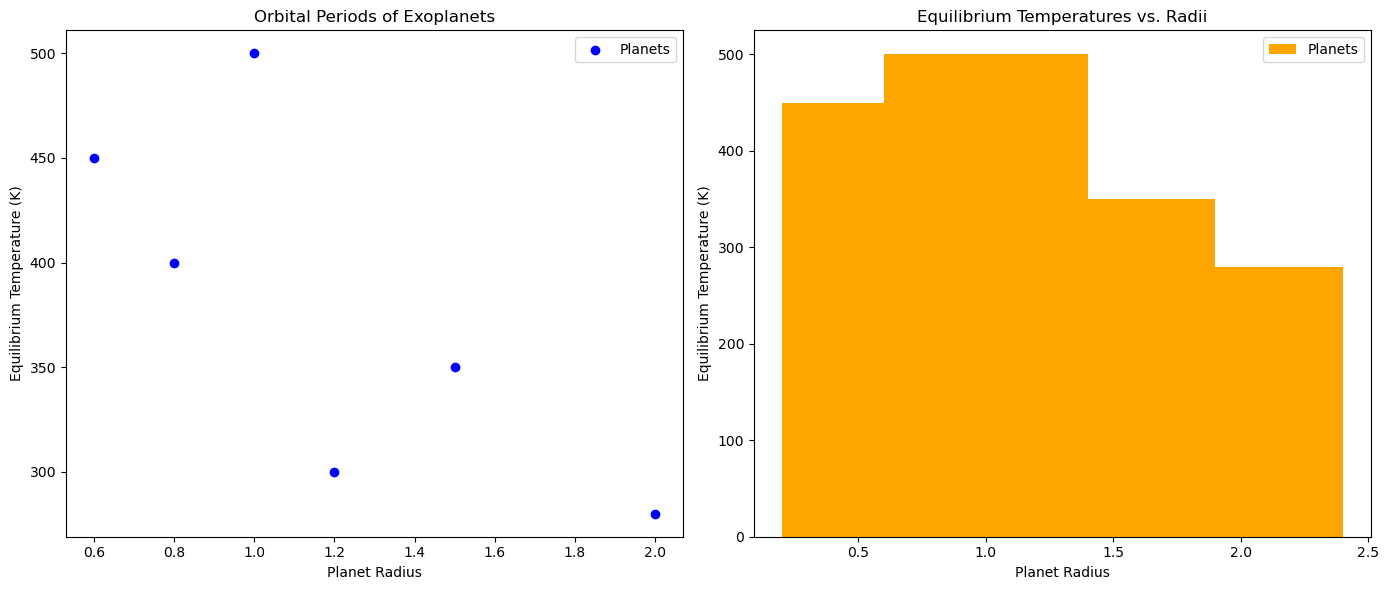

In [85]:
import matplotlib.pyplot as plt 

semi_major_axes = [0.5, 1.0, 2.0, 1.5, 1.2, 0.8]
radii = [1.2, 0.8, 1.5, 2.0, 1.0, 0.6] 
temperatures = [300, 400, 350, 280, 500, 450]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(radii, temperatures, color='blue', label='Planets')
axs[0].set_xlabel('Planet Radius')
axs[0].set_ylabel('Equilibrium Temperature (K)')
axs[0].set_title('Orbital Periods of Exoplanets')
axs[0].legend()

axs[1].bar(radii, temperatures, color='orange', label='Planets')
axs[1].set_xlabel('Planet Radius')
axs[1].set_ylabel('Equilibrium Temperature (K)')
axs[1].set_title('Equilibrium Temperatures vs. Radii')
axs[1].legend()

plt.tight_layout()
plt.show()

Put the scatter plot and bar plot on the same figure (horizonatally). 

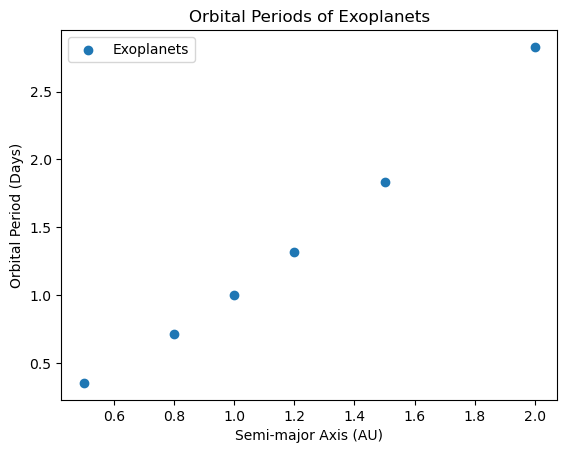

In [83]:
import matplotlib.pyplot as plt

# Data for semi-major axes and orbital periods
semi_major_axes = [0.5, 1.0, 2.0, 1.5, 1.2, 0.8]
orbital_periods = [orbital_period(0.5), orbital_period(1.0), orbital_period(2.0),orbital_period(1.5),orbital_period(1.2), orbital_period(0.8)]  

plt.scatter(semi_major_axes, orbital_periods, label="Exoplanets")

plt.xlabel('Semi-major Axis (AU)')
plt.ylabel('Orbital Period (Days)')
plt.title('Orbital Periods of Exoplanets')

plt.legend()

plt.show()

## 5 Modules
Choose a function from this homework and put it into a module. Import the module with the function below. Make sure to show the output.

In [126]:
from orbital_period_function import orbital_period

print(orbital_period(2))

2.8284271247461903
